# EDA for Price Model

*Is there a time of year when we get the best prices on the items we buy most often, and what should we be thinking about when we decide what to purchase when?*.  

Notes from `notebooks/pm_eda.ipynb`:
```python
# Insights so far

## Data inconsistencies and errors:

# There's inconsistencies between headers and lines on customer_ids. I'll assume that headers are correct.
# Silver lines table has duplicates. I'll drop them and make the fix on gold too.
# There's items that are not in the item_pricing table, appeared only once in history and header was computed
# as if the item was not on the order, I'll set these aside 

## Insights

# Customers don't seem to be paying list price. At least for CUST-A, they are paying around 6% off list price.
# ITM-0902 has multiple and significant price jumps
# There is no seasonal month or weekday with apparent best prices
# CUST-A Get's better prices than other customers: On the same item, the same vendor, and the same month, A's median paid price is 0.94 times the other customers' median (858 overlapping cells; the middle half sits between 0.92 and 0.97). 
# Prices are slowly increasing over time
# It doesn't look like there's a relationship between quantity ordered and price paid (no volume discounts)
```

In [ ]:
import os
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch


DATA_DIR = os.environ.get("DATA_DIR", "../data")
conn = duckdb.connect(f"{DATA_DIR}/warehouse.duckdb", read_only=True)
sns.set_theme(style="whitegrid", context="notebook")

In [2]:
# Company A's lines: one row is one line on an order.
# Cancelled orders are not purchases, so they stay out of both rankings.
# `extended` is the dollars on that line. It is blank when the unit price is missing.

lines = conn.sql("""
    SELECT
        po_number,
        item_id,
        category,
        unit_of_measure,
        order_date,
        vendor_id,
        quantity_ordered,
        unit_price_paid,
        status
    FROM gold.fct_company_a_purchase_line
    WHERE status <> 'Cancelled'
""").df()

lines["order_date"] = pd.to_datetime(lines["order_date"])
lines["extended"] = lines["quantity_ordered"] * lines["unit_price_paid"]

n_orders = lines["po_number"].nunique()
window = f"{lines['order_date'].min():%b %Y} – {lines['order_date'].max():%b %Y}"

print(lines["status"].value_counts())
print(f"{n_orders} orders, {lines['item_id'].nunique()} items, {window}")

status
Received    1337
Closed       670
Open         136
Name: count, dtype: int64
770 orders, 120 items, Jan 2024 – Sep 2026


In [3]:
lines.head(2)

,po_number,item_id,category,unit_of_measure,order_date,vendor_id,quantity_ordered,unit_price_paid,status,extended
0,PO-100000,ITM-0431,Wiring devices,EA,2024-04-01,VEND-06,10,0.72,Closed,7.2
1,PO-100003,ITM-0201,Conduit & fittings,EA,2024-06-28,VEND-09,24,3.80,Closed,91.2


In [9]:
# One row per item, so "how often" and "how much money" can be ranked separately.
# An item counts once per order, even when that order has two lines for it.
# Eligible items were bought in at least 8 different months and across a full year.
# Anything shorter cannot answer "is there a better time of year".

items = (
    lines.groupby(["item_id", "category", "unit_of_measure"], as_index=False)
    .agg(
        n_orders=("po_number", "nunique"),
        n_lines=("po_number", "size"),
        n_months=("order_date", lambda s: s.dt.to_period("M").nunique()),
        first_order=("order_date", "min"),
        last_order=("order_date", "max"),
        n_vendors=("vendor_id", "nunique"),
        median_qty=("quantity_ordered", "median"),
        total_spend=("extended", "sum"),
        n_priced=("unit_price_paid", "count"),
    )
)

items["span_days"] = (items["last_order"] - items["first_order"]).dt.days
items["attachment"] = items["n_orders"] / n_orders
# Reorder rate over the stretch they were actually buying it.
# A three-month burst can score high here and still fail the span floor.
items["orders_per_month"] = items["n_orders"] / (items["span_days"] / 30.44).clip(lower=1)

SPAN_MONTHS = 8
SPAN_DAYS = 365
items["eligible"] = (items["n_months"] >= SPAN_MONTHS) & (items["span_days"] >= SPAN_DAYS)

often = items[items["eligible"]].sort_values("n_orders", ascending=False)
in_size = items[items["eligible"]].sort_values("total_spend", ascending=False)

print(
    "Share of orders that include the item:\n",
    items["attachment"].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99])
)
print(f"\n{items['eligible'].sum()} of {len(items)} items have a long enough history to compare seasons")

Share of orders that include the item:
 count    120.000000
mean       0.023193
std        0.028918
min        0.001299
25%        0.006494
50%        0.012338
75%        0.026299
90%        0.049870
95%        0.082013
99%        0.148870
max        0.155844
Name: attachment, dtype: float64

66 of 120 items have a long enough history to compare seasons


In [14]:
print("Nb items that appear in over 75% of orders",len(items[items["attachment"] > np.percentile(items["attachment"], 75)]))
print("Nb items that appear in over 80% of orders",len(items[items["attachment"] > np.percentile(items["attachment"], 80)]))
print("Nb items that appear in over 85% of orders",len(items[items["attachment"] > np.percentile(items["attachment"], 85)]))
print("Nb items that appear in over 90% of orders",len(items[items["attachment"] > np.percentile(items["attachment"], 90)]))
print("Nb items that appear in over 95% of orders",len(items[items["attachment"] > np.percentile(items["attachment"], 95)]))

Nb items that appear in over 75% of orders 30
Nb items that appear in over 80% of orders 24
Nb items that appear in over 85% of orders 18
Nb items that appear in over 90% of orders 12
Nb items that appear in over 95% of orders 6


In [17]:
len(items[items["attachment"] <= np.percentile(items["attachment"], 90)])

108

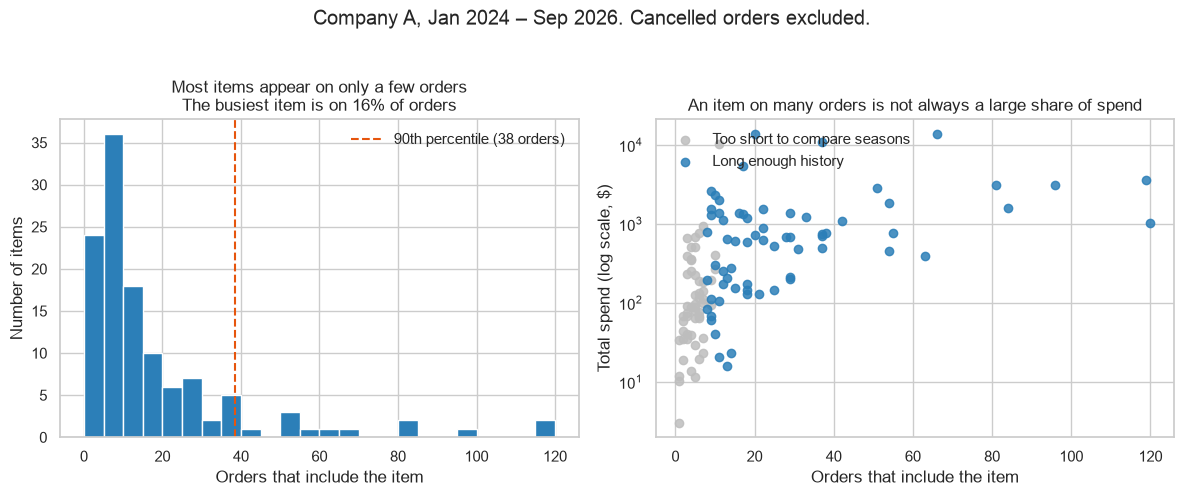

In [8]:
# Shape of the catalog, before choosing a cutoff.
# Left: "frequent" is a short right tail. The busiest item is still on a small share of orders.
# Right: order count and dollars are different rankings. Gray items are too short-lived for a seasonal comparison.

busiest_share = items["attachment"].max()
p90_orders = items["n_orders"].quantile(0.9)
history_color = {True: "#2c7fb8", False: "#bdbdbd"}
history_label = {True: "Long enough history", False: "Too short to compare seasons"}

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

axes[0].hist(
    items["n_orders"],
    bins=range(0, int(items["n_orders"].max()) + 5, 5),
    color="#2c7fb8",
    edgecolor="white",
)
axes[0].axvline(
    p90_orders,
    color="#e6550d",
    linestyle="--",
    linewidth=1.5,
    label=f"90th percentile ({p90_orders:.0f} orders)",
)
axes[0].set_title(f"Most items appear on only a few orders\nThe busiest item is on {busiest_share:.0%} of orders")
axes[0].set_xlabel("Orders that include the item")
axes[0].set_ylabel("Number of items")
axes[0].legend(frameon=False)

for is_eligible, frame in items.groupby("eligible"):
    axes[1].scatter(
        frame["n_orders"],
        frame["total_spend"],
        s=36,
        alpha=0.85,
        color=history_color[is_eligible],
        label=history_label[is_eligible],
    )
axes[1].set_yscale("log")
axes[1].set_title("An item on many orders is not always a large share of spend")
axes[1].set_xlabel("Orders that include the item")
axes[1].set_ylabel("Total spend (log scale, $)")
axes[1].legend(frameon=False, loc="upper left")

fig.suptitle(f"Company A, {window}. Cancelled orders excluded.", y=1.03)
fig.tight_layout()

In [18]:
# Same summary as attachment, now for dollars.
# `total_spend` is quantity × unit price, summed over Company A's history for that item.
# A percentile here is a dollar cutoff. The 90th percentile means 90% of items are at or below that amount.

print(
    "Total spend on the item ($):\n",
    items["total_spend"].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]),
)
print()
for percentile in [75, 80, 85, 90, 95]:
    cutoff = np.percentile(items["total_spend"], percentile)
    n_items = (items["total_spend"] > cutoff).sum()
    print(f"Above the {percentile}th percentile of spend (${cutoff:,.0f}): {n_items} items")


Total spend on the item ($):
 count      120.000000
mean       973.718750
std       2275.980304
min          3.020000
25%         77.972500
50%        227.665000
75%        766.065000
90%       1840.560000
95%       3161.804000
99%      13158.506400
max      13938.010000
Name: total_spend, dtype: float64

Above the 75th percentile of spend ($766): 30 items
Above the 80th percentile of spend ($1,092): 24 items
Above the 85th percentile of spend ($1,361): 18 items
Above the 90th percentile of spend ($1,841): 12 items
Above the 95th percentile of spend ($3,162): 6 items


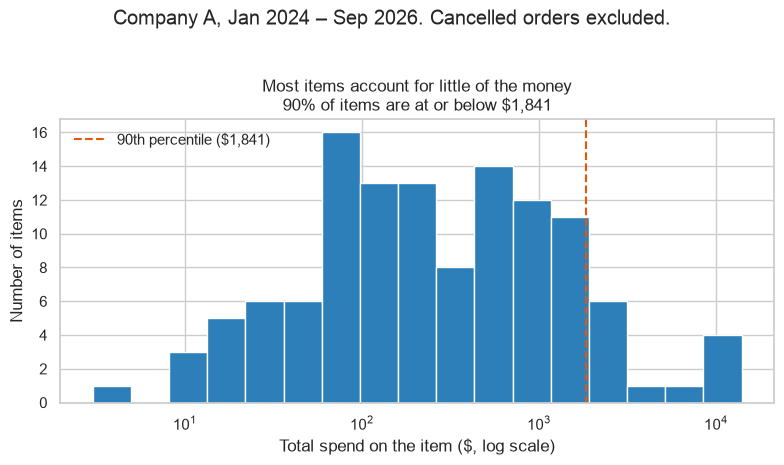

In [19]:
# Same reading as the order chart: each bar counts items.
# The dollar axis is logarithmic because spend runs from a few dollars to well over $10,000.
# On a linear axis almost every item would sit in the first bar.
# The dashed line is the 90th percentile in dollars. Items to its right spent more than 90% of the catalog.

spend = items.loc[items["total_spend"] > 0, "total_spend"]
p90_spend = spend.quantile(0.9)
bins = np.logspace(np.log10(spend.min()), np.log10(spend.max()), 18)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(spend, bins=bins, color="#2c7fb8", edgecolor="white")
ax.set_xscale("log")
ax.axvline(
    p90_spend,
    color="#e6550d",
    linestyle="--",
    linewidth=1.5,
    label=f"90th percentile (${p90_spend:,.0f})",
)
ax.set_xlabel("Total spend on the item ($, log scale)")
ax.set_ylabel("Number of items")
ax.set_title(
    f"Most items account for little of the money\n"
    f"90% of items are at or below ${p90_spend:,.0f}"
)
ax.legend(frameon=False)
fig.suptitle(f"Company A, {window}. Cancelled orders excluded.", y=1.03)
fig.tight_layout()


In [ ]:
# Ok, so far I've been exploring distributions to build these conditionals:
# - Is a "frequently" purchased item
# - Is elegible (it wasn't just purchased multiple times in a short period ot time, but constantly)
# - There's a price amount opportunity

# i'll go with p90 for frequency
# elegibility is about purchases made constantly over time, not just in a short period of time
# Median for the price amount opportunity, as the tail is subject to outliers

In [20]:
# Items that pass all three rules.

frequent_cutoff = items["attachment"].quantile(0.9)
spend_cutoff = items["total_spend"].median()

focus = items[
    (items["attachment"] > frequent_cutoff)
    & items["eligible"]
    & (items["total_spend"] > spend_cutoff)
].sort_values("n_orders", ascending=False).copy()

focus["share of orders"] = focus["attachment"].map("{:.1%}".format)
focus["spend"] = focus["total_spend"].map("${:,.0f}".format)
focus["worth of a 1% better price"] = (focus["total_spend"] / 100).map("${:,.0f}".format)

print(
    f"{len(focus)} items. "
    f"Frequent means more than {frequent_cutoff:.1%} of orders. "
    f"Spend means more than ${spend_cutoff:,.0f}."
)
focus[
    ["item_id", "category", "unit_of_measure",
     "n_orders", "share of orders", "n_months",
     "spend", "worth of a 1% better price"]
]

12 items. Frequent means more than 5.0% of orders. Spend means more than $228.


,item_id,category,unit_of_measure,n_orders,share of orders,n_months,spend,worth of a 1% better price
46,ITM-0433,Wiring devices,EA,120,15.6%,31,"$1,016",$10
64,ITM-0612,Connectors & lugs,EA,119,15.5%,33,"$3,646",$36
113,ITM-1015,Tape & sealants,EA,96,12.5%,29,"$3,136",$31
13,ITM-0237,Conduit & fittings,EA,84,10.9%,29,"$1,582",$16
1,ITM-0201,Conduit & fittings,EA,81,10.5%,33,"$3,123",$31
42,ITM-0426,Wiring devices,EA,66,8.6%,27,"$13,938",$139
23,ITM-0306,Boxes & enclosures,EA,63,8.2%,28,$391,$4
47,ITM-0434,Wiring devices,EA,55,7.1%,28,$756,$8
68,ITM-0621,Connectors & lugs,BG,54,7.0%,27,"$1,820",$18
99,ITM-0929,Fasteners & supports,EA,54,7.0%,27,$458,$5


In [23]:
opportunity_items = list(focus["item_id"])

df_frequent = lines[lines["item_id"].isin(opportunity_items)].copy()
len(df_frequent)

885

In [25]:
# One monthly index for the frequent items, then two ways to take out the rise.
# Relative price is the paid price divided by that item's own median. 1.00 is typical for the item.
# Each item counts equally: the median inside the item-month, then the median across items.
# YoY is this index versus the same month a year earlier. A steady rise becomes a flat rate.
# The detrend is a straight line. A 12-month moving average would blank the first and last
# six months, which removes most of 2024 and the partial 2026.

priced = df_frequent.dropna(subset=["unit_price_paid"]).copy()
priced["relative_price"] = (
    priced["unit_price_paid"]
    / priced.groupby("item_id")["unit_price_paid"].transform("median")
)
priced["year_month"] = priced["order_date"].dt.to_period("M")

item_month = priced.groupby(["item_id", "year_month"], as_index=False)["relative_price"].median()
monthly = item_month.groupby("year_month")["relative_price"].median().sort_index()
monthly.index = monthly.index.to_timestamp()
monthly = monthly.reindex(pd.date_range(monthly.index.min(), monthly.index.max(), freq="MS"))
monthly.name = "relative_price"

missing_months = monthly.index[monthly.isna()]
if len(missing_months):
    print("Months with no purchase:", ", ".join(missing_months.strftime("%b %Y")))
else:
    print(f"{monthly.index.min():%b %Y} to {monthly.index.max():%b %Y}, no empty months")

yoy = monthly.pct_change(12).rename("yoy")

t = np.arange(len(monthly), dtype=float)
observed = np.isfinite(monthly.to_numpy(dtype=float))
slope, intercept = np.polyfit(t[observed], monthly.to_numpy(dtype=float)[observed], 1)
trend = pd.Series(slope * t + intercept, index=monthly.index, name="trend")
detrended = (monthly - trend).rename("detrended")

season = pd.DataFrame({
    "relative_price": monthly,
    "yoy": yoy,
    "trend": trend,
    "detrended": detrended,
})
season["year"] = season.index.year
season["month"] = season.index.month

month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
month_effect = detrended.groupby(detrended.index.month).mean()
print(f"Straight-line rise: {slope:.2%} of a typical price per month ({slope * 12:.1%} a year)")
print("Average gap versus that line, by calendar month:")
print(month_effect.map(lambda value: f"{value:+.1%}").rename(index=dict(enumerate(month_names, start=1))))


Jan 2024 to Sep 2026, no empty months
Straight-line rise: 0.24% of a typical price per month (2.8% a year)
Average gap versus that line, by calendar month:
Jan    -0.2%
Feb    -0.7%
Mar    +0.2%
Apr    +0.5%
May    +0.2%
Jun    +0.1%
Jul    -0.6%
Aug    -0.2%
Sep    -0.0%
Oct    +1.7%
Nov    +0.2%
Dec    -0.7%
Name: detrended, dtype: str


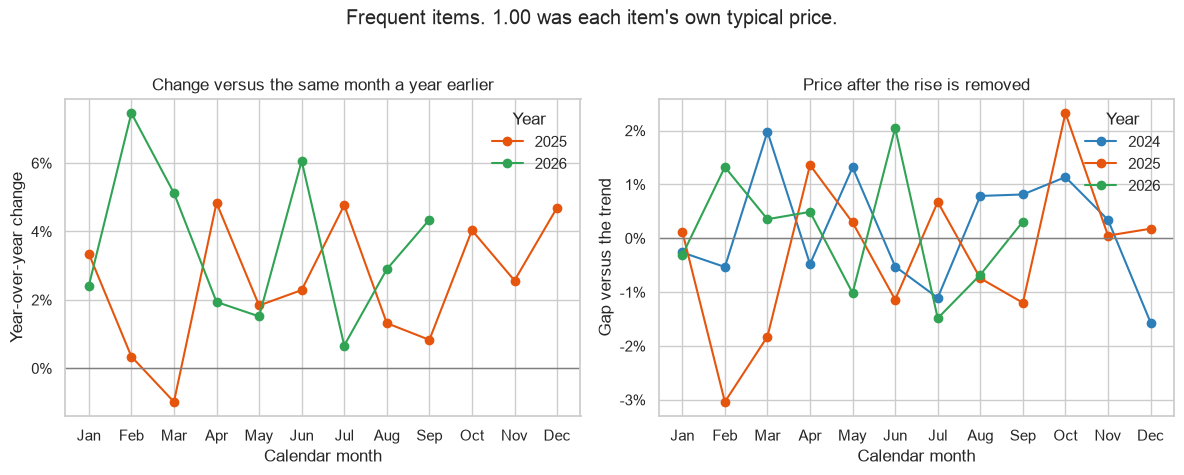

In [26]:
# Each year drawn on the same January-to-December axis.
# Left: change versus the same month last year. 2024 has no prior year, so it is absent.
# A shared cheap month would dip in both 2025 and 2026.
# Right: the index after the straight-line rise is removed. 0 means "on the trend".
# A shared season would make the three lines bend the same way.

year_color = {2024: "#2c7fb8", 2025: "#e6550d", 2026: "#31a354"}

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))

for year, frame in season.dropna(subset=["yoy"]).groupby("year"):
    axes[0].plot(frame["month"], frame["yoy"], marker="o", color=year_color[year], label=str(year))
axes[0].axhline(0, color="gray", linewidth=1)
axes[0].set_title("Change versus the same month a year earlier")
axes[0].set_ylabel("Year-over-year change")
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:.0%}"))

for year, frame in season.dropna(subset=["detrended"]).groupby("year"):
    axes[1].plot(
        frame["month"], frame["detrended"], marker="o", color=year_color[year], label=str(year)
    )
axes[1].axhline(0, color="gray", linewidth=1)
axes[1].set_title("Price after the rise is removed")
axes[1].set_ylabel("Gap versus the trend")
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:.0%}"))

for ax in axes:
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(month_names)
    ax.set_xlabel("Calendar month")
    ax.legend(title="Year", frameon=False)

fig.suptitle("Frequent items. 1.00 was each item's own typical price.", y=1.03)
fig.tight_layout()


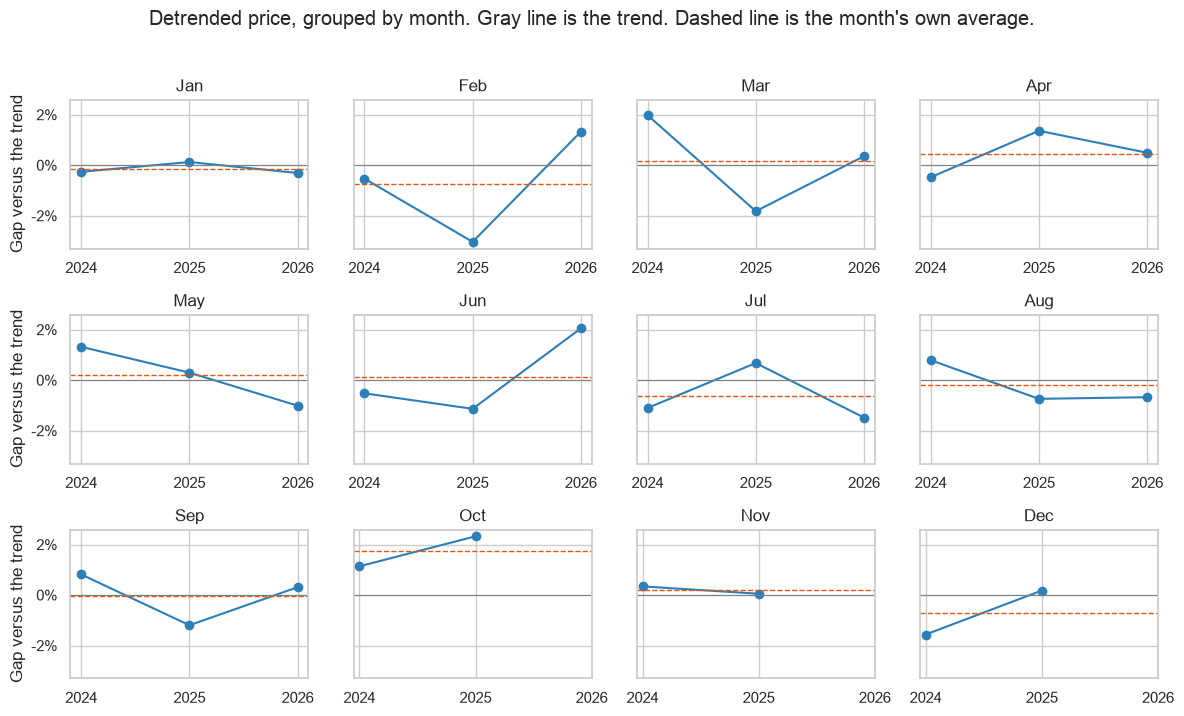

In [27]:
# One panel per calendar month. The points are that month in 2024, 2025, and 2026.
# The dashed line is the average of those points. The panels share a vertical scale,
# so a month that sits lower than the others is a cheaper month.
# A month that is consistently cheap has every point near the dashed line, and that line below zero.

fig, axes = plt.subplots(3, 4, figsize=(12, 7), sharey=True)

for month in range(1, 13):
    ax = axes.flat[month - 1]
    frame = season.loc[season["month"] == month].dropna(subset=["detrended"])
    ax.plot(frame["year"], frame["detrended"], marker="o", color="#2c7fb8")
    ax.axhline(frame["detrended"].mean(), color="#e6550d", linestyle="--", linewidth=1)
    ax.axhline(0, color="gray", linewidth=0.8)
    ax.set_title(month_names[month - 1])
    ax.set_xticks([2024, 2025, 2026])

for ax in axes[:, 0]:
    ax.set_ylabel("Gap versus the trend")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:.0%}"))

fig.suptitle(
    "Detrended price, grouped by month. Gray line is the trend. Dashed line is the month's own average.",
    y=1.02,
)
fig.tight_layout()


In [30]:
# Change from the previous calendar month, separately for each frequent item.
# (price this month − price previous month) / price previous month.
# The price is the item's monthly median, divided by that item's own typical price.
# A month with no purchase stays missing, so the change is not taken against an older month.

priced = df_frequent.dropna(subset=["unit_price_paid"]).copy()
priced["relative_price"] = (
    priced["unit_price_paid"]
    / priced.groupby("item_id")["unit_price_paid"].transform("median")
)
priced["year_month"] = priced["order_date"].dt.to_period("M").dt.to_timestamp()

item_month = priced.groupby(["item_id", "year_month"], as_index=False)["relative_price"].median()
months = pd.date_range(item_month["year_month"].min(), item_month["year_month"].max(), freq="MS")

frames = []
for item_id in focus["item_id"]:
    series = (
        item_month.loc[item_month["item_id"] == item_id]
        .set_index("year_month")["relative_price"]
        .reindex(months)
    )
    series.index.name = "year_month"
    frame = series.rename("relative_price").reset_index()
    frame["item_id"] = item_id
    frame["mom"] = series.pct_change().to_numpy()
    frames.append(frame)

by_item = pd.concat(frames, ignore_index=True)
by_item["year"] = by_item["year_month"].dt.year
by_item["month"] = by_item["year_month"].dt.month

print(f"{by_item['item_id'].nunique()} items, {months.min():%b %Y} to {months.max():%b %Y}")


12 items, Jan 2024 to Sep 2026


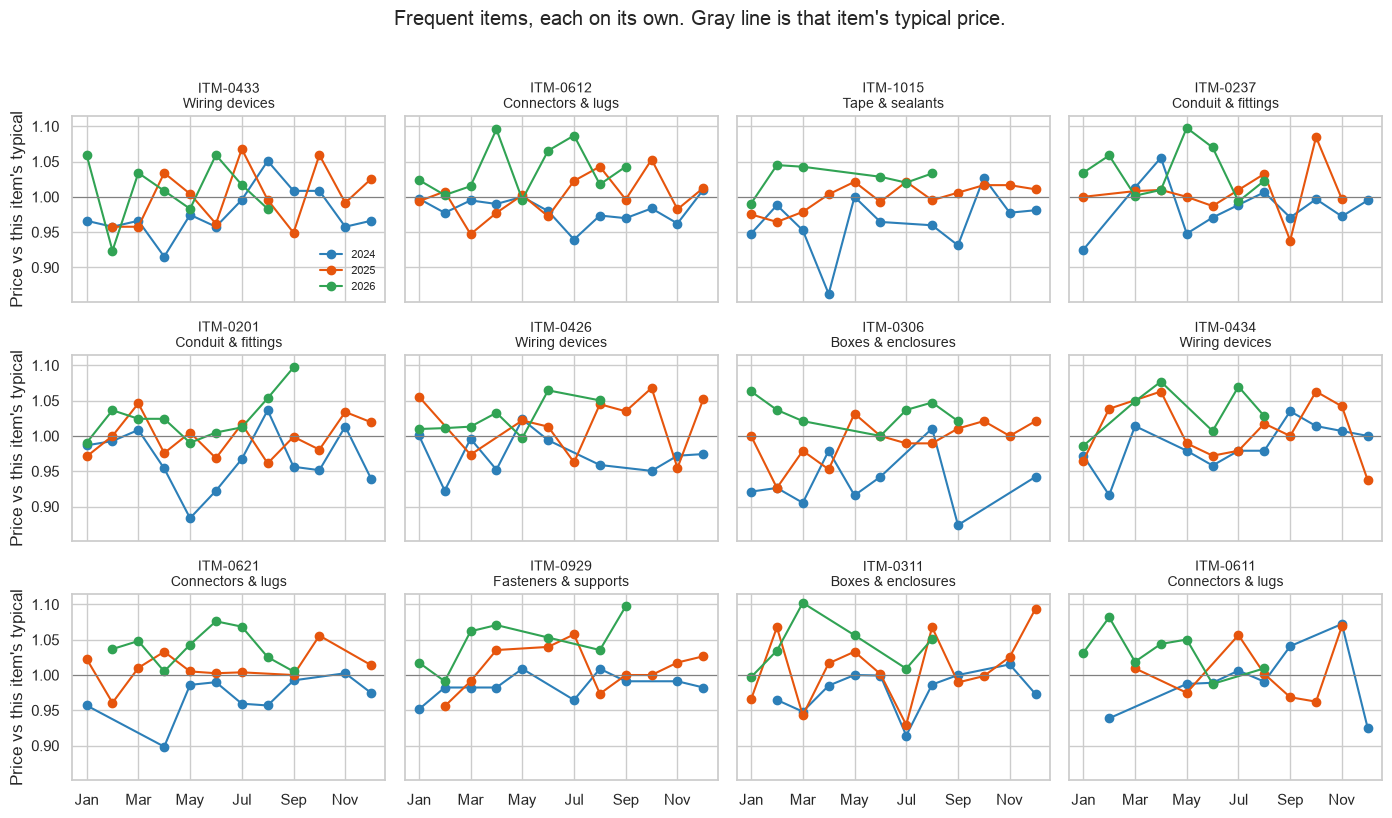

In [31]:
# One panel per item. Each line is a year, January to December.
# 1.00 is that item's own typical price. A cheap season would sit below 1 in the same month every year.

item_order = focus["item_id"].tolist()
categories = focus.set_index("item_id")["category"]
fig, axes = plt.subplots(3, 4, figsize=(14, 8), sharex=True, sharey=True)

for ax, item_id in zip(axes.flat, item_order):
    frame = by_item.loc[by_item["item_id"] == item_id].dropna(subset=["relative_price"])
    for year, year_frame in frame.groupby("year"):
        ax.plot(
            year_frame["month"],
            year_frame["relative_price"],
            marker="o",
            color=year_color[year],
            label=str(year),
        )
    ax.axhline(1, color="gray", linewidth=0.8)
    ax.set_title(f"{item_id}\n{categories[item_id]}", fontsize=10)
    ax.set_xticks(range(1, 13, 2))
    ax.set_xticklabels([month_names[month - 1] for month in range(1, 13, 2)])

axes[0, 0].legend(frameon=False, fontsize=8)
for ax in axes[:, 0]:
    ax.set_ylabel("Price vs this item's typical")
fig.suptitle("Frequent items, each on its own. Gray line is that item's typical price.", y=1.02)
fig.tight_layout()


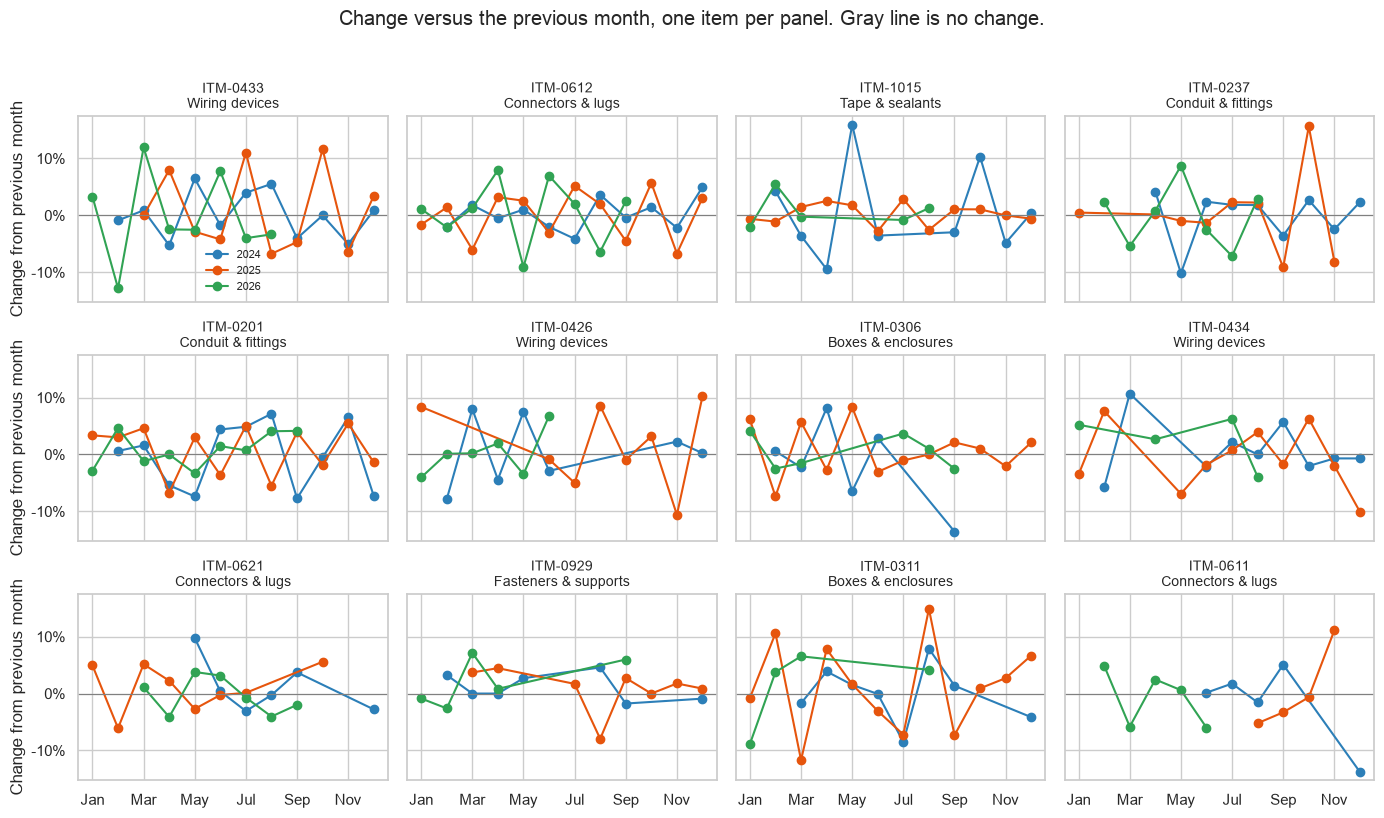

In [32]:
# Same panels, for the change from the previous month.
# Zero means the same price as the month before. A shared cheap month would dip there in every year.

fig, axes = plt.subplots(3, 4, figsize=(14, 8), sharex=True, sharey=True)

for ax, item_id in zip(axes.flat, item_order):
    frame = by_item.loc[by_item["item_id"] == item_id].dropna(subset=["mom"])
    for year, year_frame in frame.groupby("year"):
        ax.plot(
            year_frame["month"],
            year_frame["mom"],
            marker="o",
            color=year_color[year],
            label=str(year),
        )
    ax.axhline(0, color="gray", linewidth=0.8)
    ax.set_title(f"{item_id}\n{categories[item_id]}", fontsize=10)
    ax.set_xticks(range(1, 13, 2))
    ax.set_xticklabels([month_names[month - 1] for month in range(1, 13, 2)])
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:.0%}"))

axes[0, 0].legend(frameon=False, fontsize=8)
for ax in axes[:, 0]:
    ax.set_ylabel("Change from previous month")
fig.suptitle("Change versus the previous month, one item per panel. Gray line is no change.", y=1.02)
fig.tight_layout()


In [ ]:
# 1. ITM-0201 (Conduit & fittings) — Early Spring (April - May)
# This item has a very distinct, predictable price drop in the spring.
# • The Pattern: Every single year, the price drops sharply between March and May.
# • The Low Period: April and May are consistently the lowest months, dipping down to roughly 0.88 to 0.96 of the item's typical price before recovering in the summer.

# 2. ITM-1015 (Tape & sealants) — Winter / Start of the Year (January)
# This item consistently starts the calendar year at its lowest point.
# • The Pattern: The blue, orange, and green lines are all closely bunched together below the 1.0 baseline at the very beginning of the X-axis.
# • The Low Period: January is consistently a low-priced month for this item, hovering between 0.95 and 0.98 of its typical price.

# 3. ITM-0434 (Wiring devices) — Late Winter / Start of the Year (January & February)
# Similar to the tape item, this wiring device shows a reliable dip at the very start of the year.
# • The Pattern: While the rest of the year features wild, overlapping swings, the lines converge tightly at the beginning of the chart.
# • The Low Period: January and February are consistently lower than the rest of the year, tracking between 0.92 and 0.97 of the baseline.


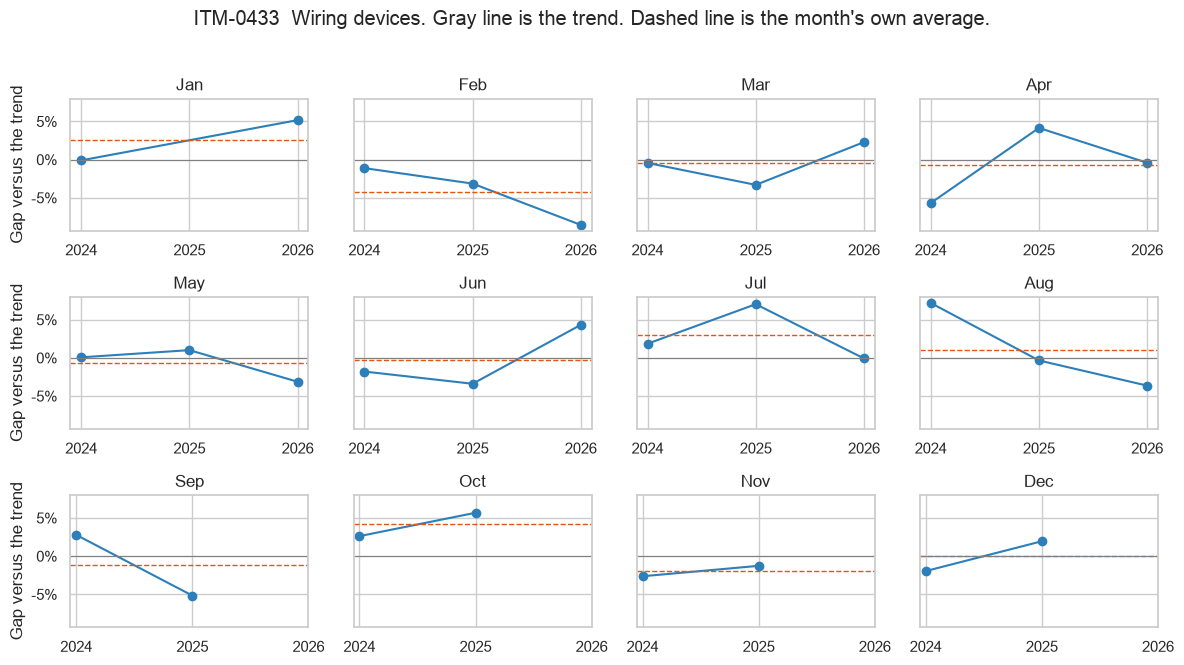

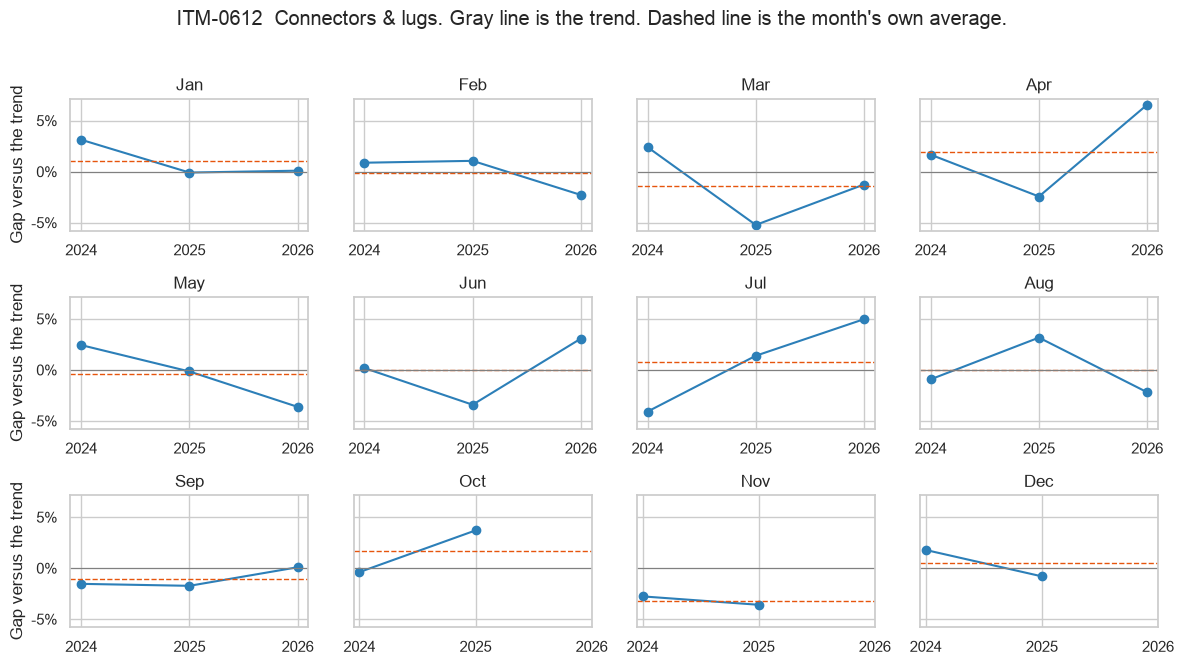

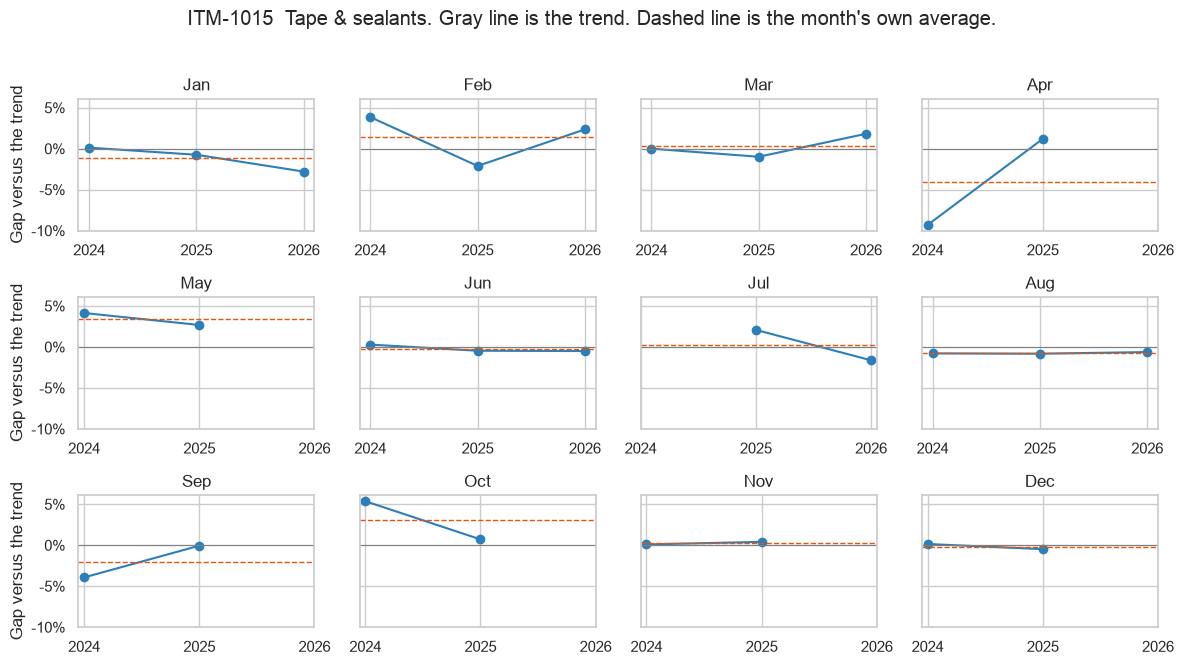

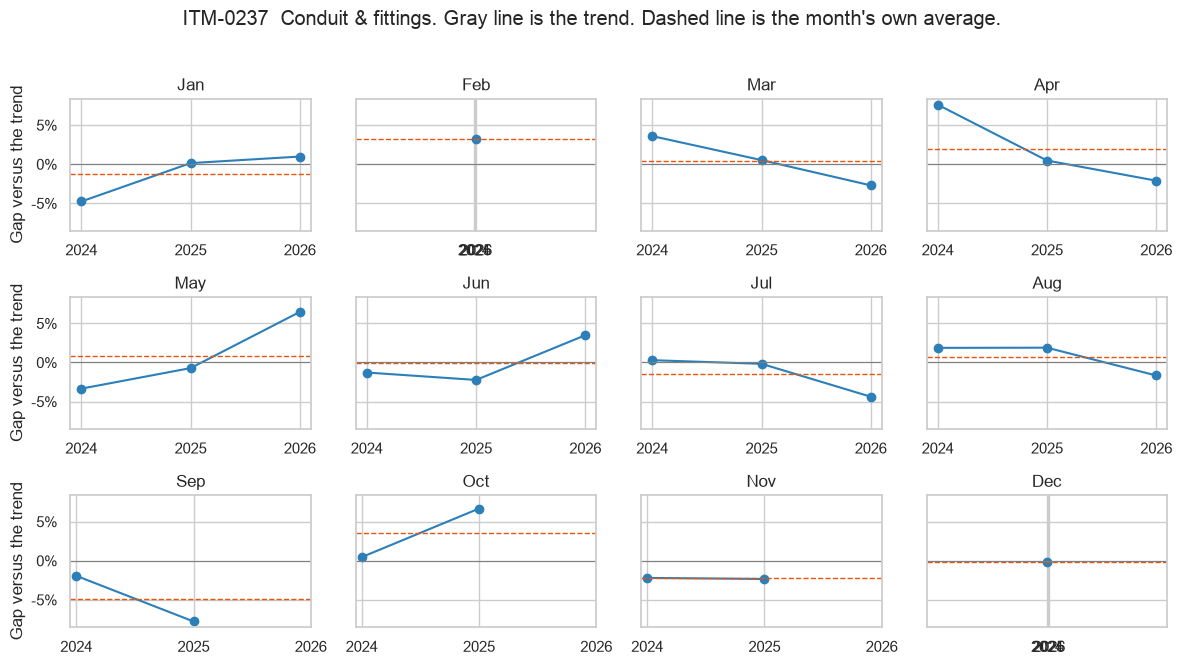

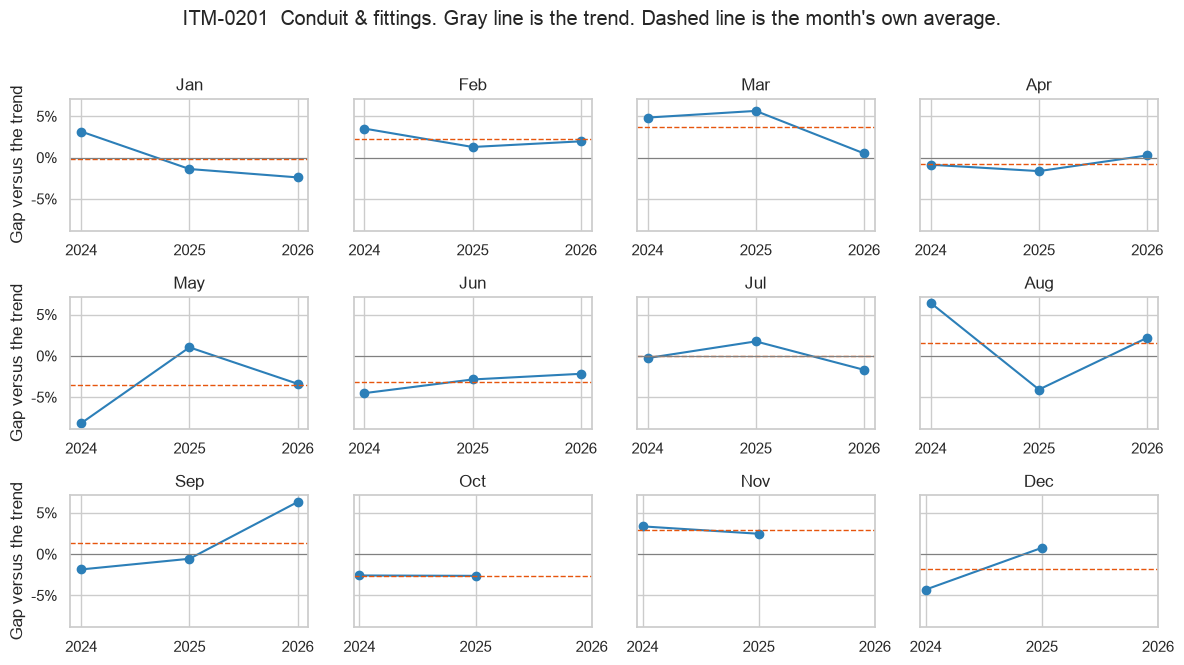

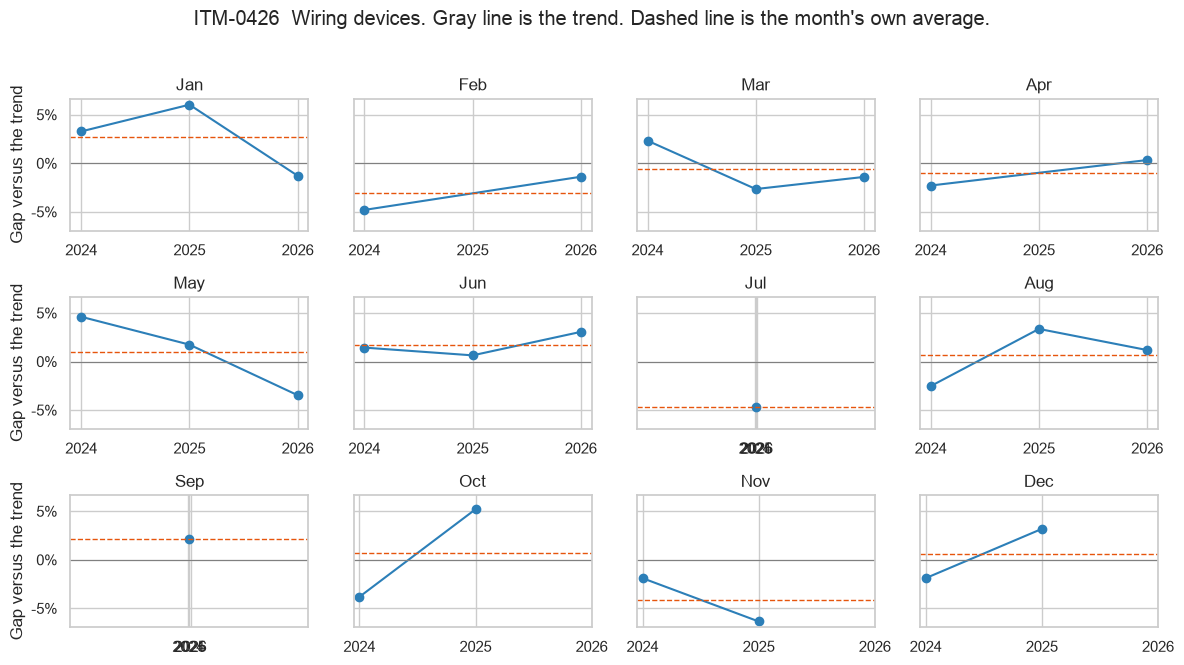

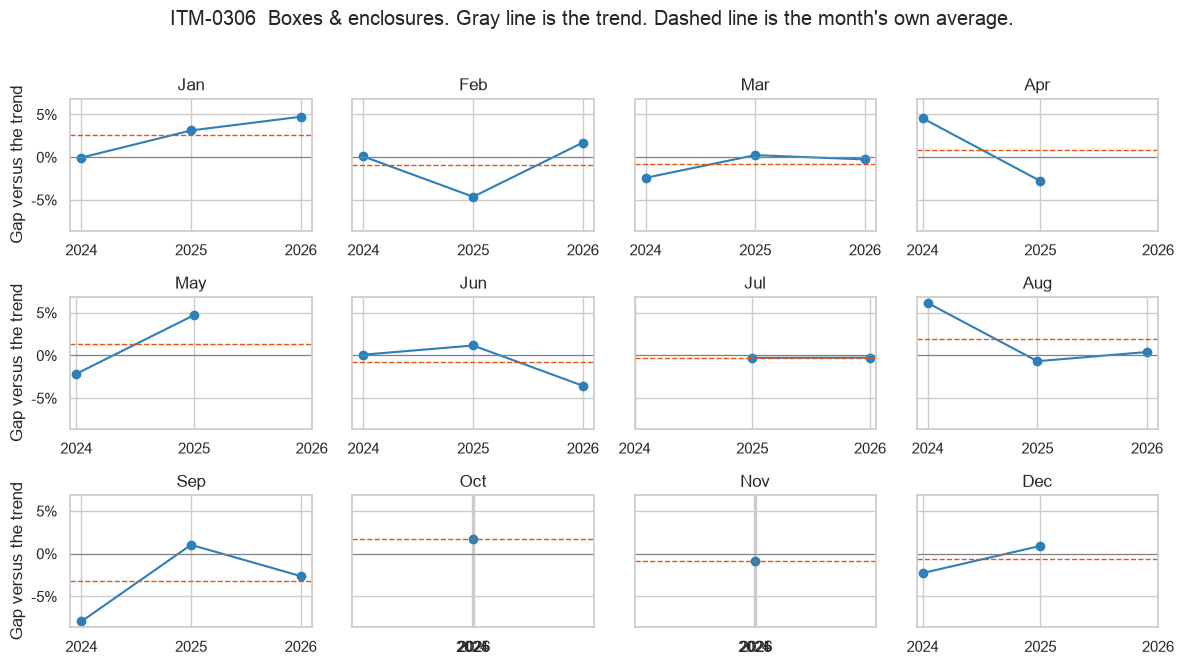

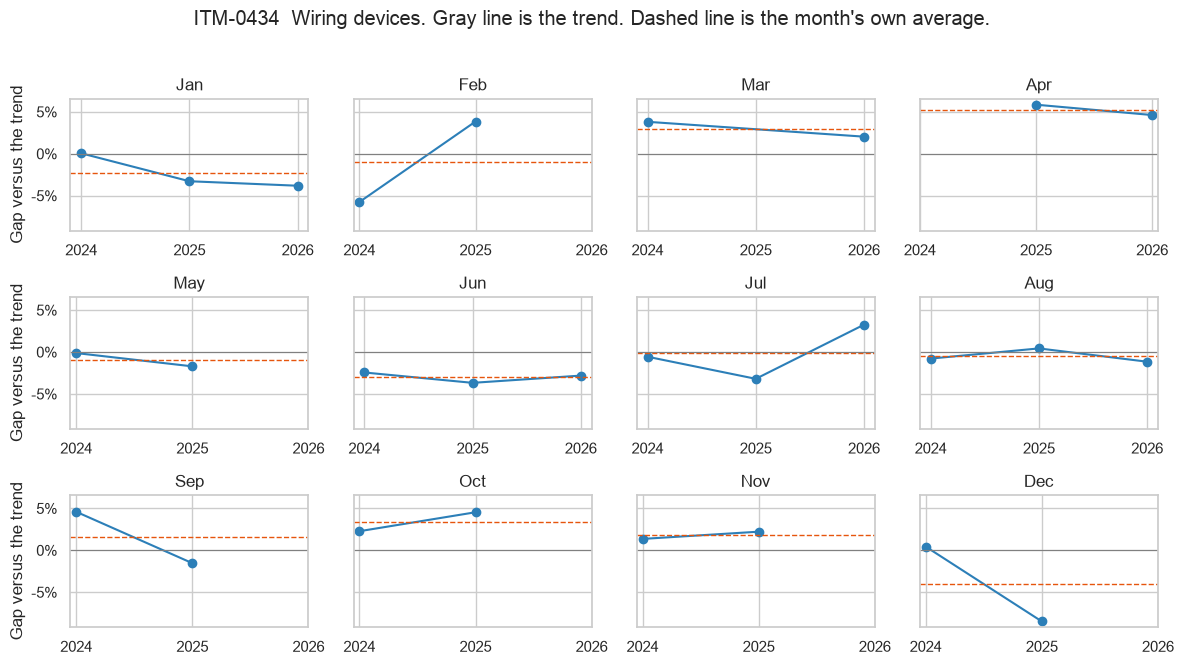

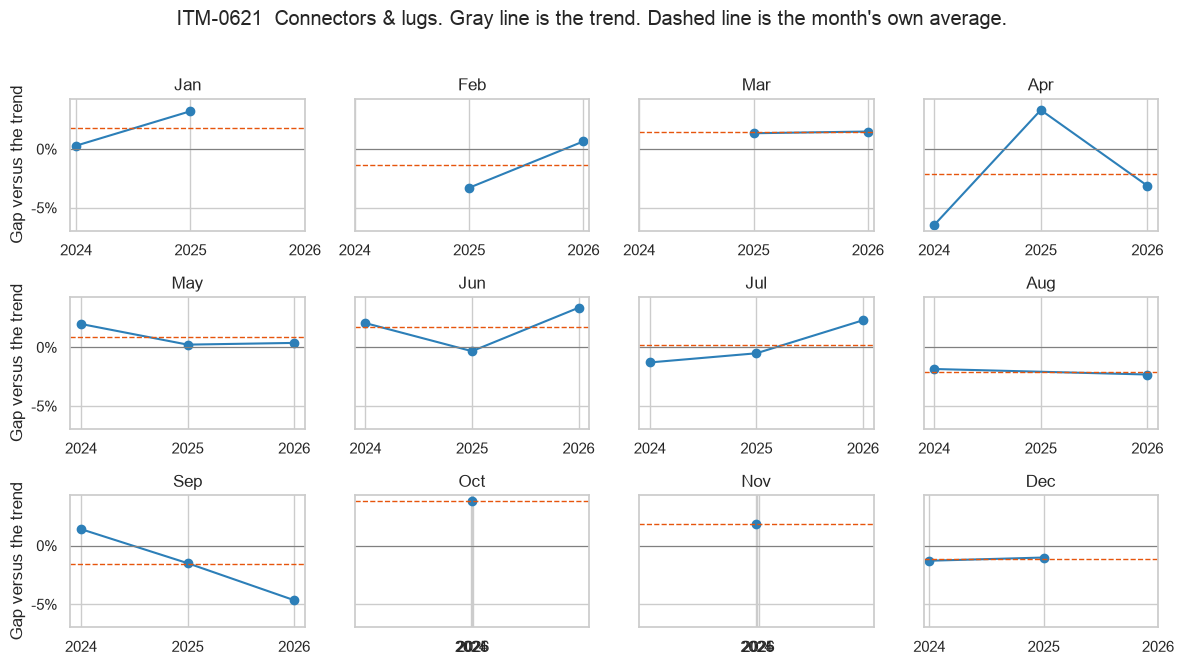

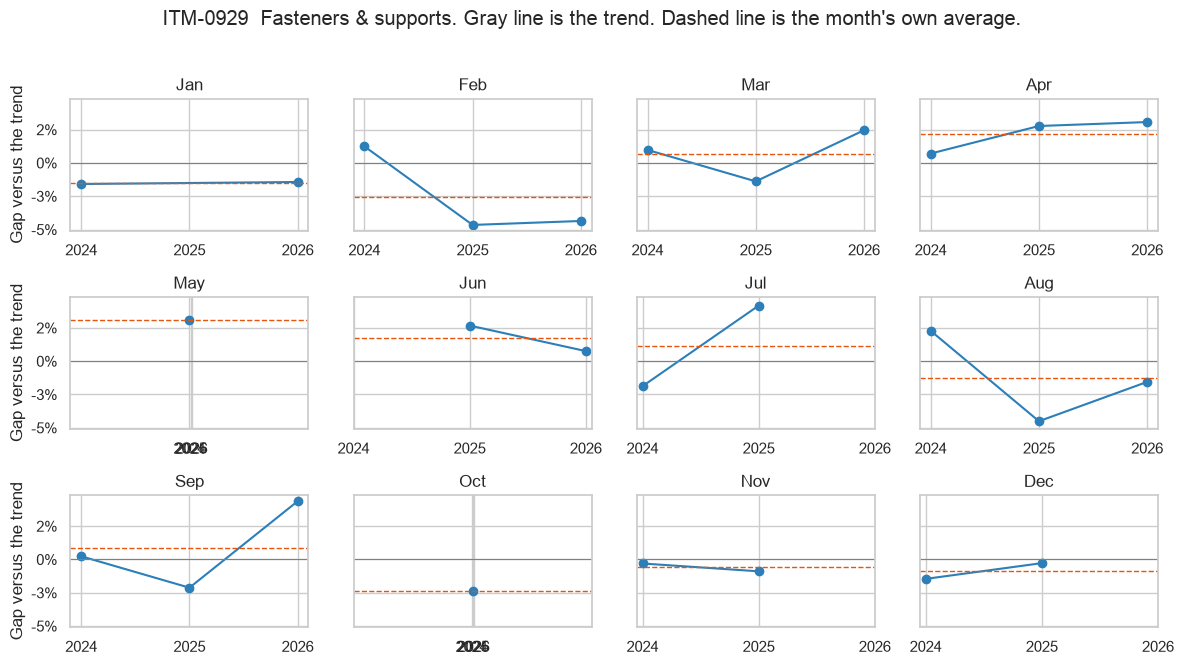

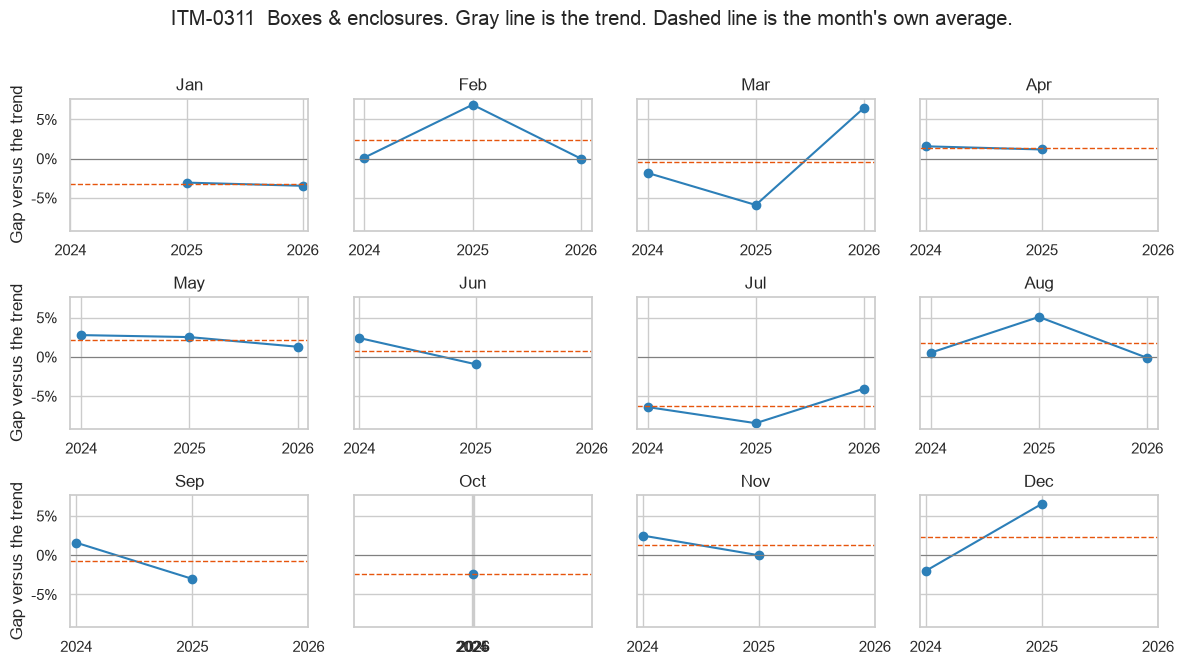

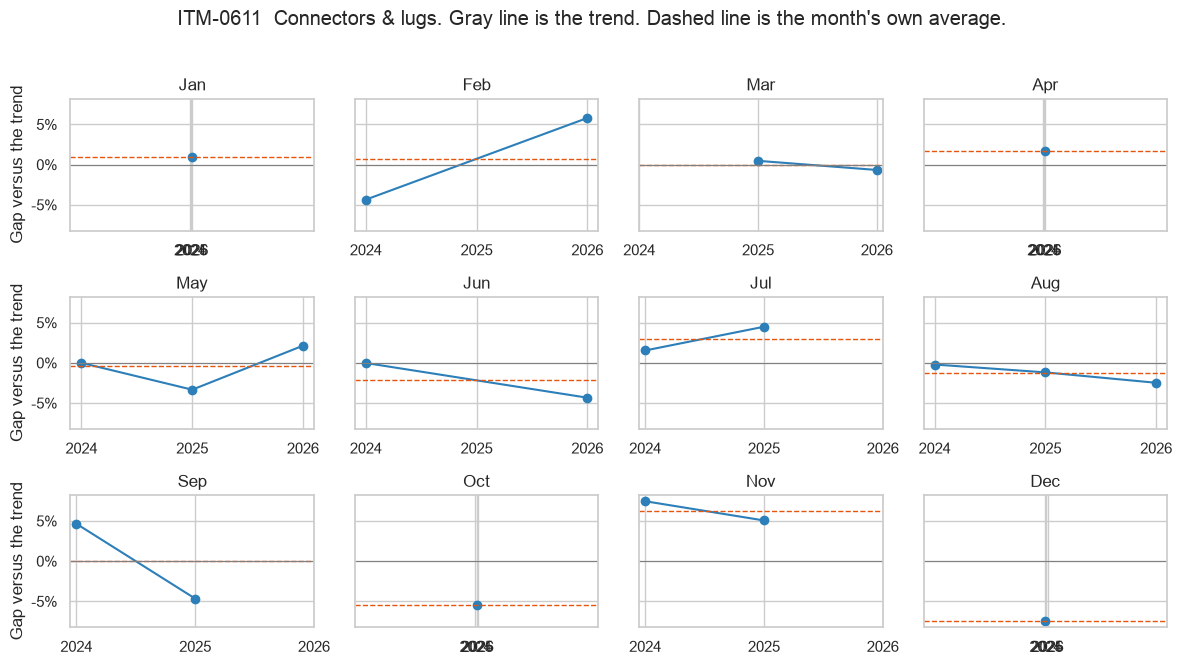

In [ ]:
# Seasonal subseries for each frequent item.
# A straight line is fit to that item's monthly price, after dividing by its own typical price.
# Each panel is one calendar month. The points are 2024, 2025, and 2026.
# The gray line is the trend. The dashed line is that month's average.
# A cheap month sits below zero, with the points close to the dashed line.

def straight_line(frame):
    mask = frame["relative_price"].notna().to_numpy()
    t = np.arange(len(frame), dtype=float)
    slope, intercept = np.polyfit(t[mask], frame.loc[mask, "relative_price"].to_numpy(dtype=float), 1)
    return slope * t + intercept

pieces = []
for item_id, frame in by_item.groupby("item_id", sort=False):
    frame = frame.sort_values("year_month").copy()
    if frame["relative_price"].notna().sum() < 2:
        frame["detrended"] = np.nan
    else:
        frame["detrended"] = frame["relative_price"] - straight_line(frame)
    pieces.append(frame)

by_item_detrended = pd.concat(pieces, ignore_index=True)
categories = focus.set_index("item_id")["category"]

for item_id in focus["item_id"]:
    item = by_item_detrended.loc[by_item_detrended["item_id"] == item_id]
    fig, axes = plt.subplots(3, 4, figsize=(12, 6.5), sharey=True)
    for month in range(1, 13):
        ax = axes.flat[month - 1]
        frame = item.loc[item["month"] == month].dropna(subset=["detrended"])
        ax.plot(frame["year"], frame["detrended"], marker="o", color="#2c7fb8")
        if len(frame):
            ax.axhline(frame["detrended"].mean(), color="#e6550d", linestyle="--", linewidth=1)
        ax.axhline(0, color="gray", linewidth=0.8)
        ax.set_title(month_names[month - 1])
        ax.set_xticks([2024, 2025, 2026])
    for ax in axes[:, 0]:
        ax.set_ylabel("Gap versus the trend")
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:.0%}"))
    fig.suptitle(
        f"{item_id}  {categories[item_id]}. Gray line is the trend. Dashed line is the month's own average.",
        y=1.02,
    )
    fig.tight_layout()


In [ ]:
#  RAW NOTES:

# ITM-0433 Feb is consistenly lower than baseline
# ITM-0612 Sept is also below or equal to baseline. And November's data shows previous years are also below baseline
# ITM-1015: Jan is at baseline or lower, Jun is relatively neutral, August is constantly lower. Nov and Dec as neutral with current data.
# ITM-0237: Sept and Nov show lower prices than baseline with current data
# ITM-0201: April is below or at baseline, Jun is consistenly below baseline, Oct is consistenly below baseline with current data
# ITM-0426: Feb is below baseline but not all years have data, Apr is below baseline but not all years have data, Nov is consistenly below baseline with current data,
# ITM-0306: March is neutral, July looks neutral but there's no data from 2024
# ITM-0434: Jan looks consistenly low, Aug is neutral, 
# ITM-0621: Aug looks like lower than baseline but we have no data from 2025, and Dec same but no data from 2026
# ITM-0929: Jan looks lower than baseline but no data from 2025
# ITM-0311: Jan looks lower than baseline but no data from 2024, July is well under the baseline constantly
# ITM-0611: August is constantly under of at baseline

In [34]:
# Dollars behind a month that sits on the same side of the item's trend every year with a purchase.
# `gap` is that month's average detrended relative price. -0.06 is 6% under the trend.
# The history is valued at the item's median unit price, which is the base of that relative price.

observed = (
    by_item_detrended.dropna(subset=["detrended"])
    .groupby(["item_id", "month", "year"], as_index=False)["detrended"]
    .mean()
)

month_gap = (
    observed.groupby(["item_id", "month"], as_index=False)
    .agg(
        n_years=("year", "nunique"),
        gap=("detrended", "mean"),
        years=("year", lambda s: ",".join(str(y) for y in sorted(s))),
    )
)
month_gap["same_side"] = month_gap["n_years"].eq(
    observed.groupby(["item_id", "month"])["detrended"].apply(lambda s: (s < 0).all() | (s > 0).all()).values
)
# Rebuild the same-side flag directly, so the row order cannot drift.
under = observed.groupby(["item_id", "month"])["detrended"].apply(lambda s: bool((s < 0).all()))
over = observed.groupby(["item_id", "month"])["detrended"].apply(lambda s: bool((s > 0).all()))
month_gap = month_gap.drop(columns="same_side").merge(
    under.rename("all_under").reset_index(), on=["item_id", "month"]
).merge(
    over.rename("all_over").reset_index(), on=["item_id", "month"]
)

median_price = priced.groupby("item_id")["unit_price_paid"].transform("median")
valued = priced.assign(
    month=priced["year_month"].dt.month,
    typical_extended=priced["quantity_ordered"] * median_price,
).merge(
    by_item_detrended[["item_id", "year_month", "detrended"]],
    on=["item_id", "year_month"],
    how="left",
)

def timing_dollars(month_rows):
    records = []
    for row in month_rows.itertuples(index=False):
        part = valued.loc[valued["item_id"] == row.item_id]
        outside = part["month"] != row.month
        # Keep the trend on the date they bought. Swap in this month's average gap.
        # A line already bought in this month is worth nothing more.
        savings = (
            part.loc[outside, "typical_extended"]
            * (part.loc[outside, "detrended"] - row.gap)
        ).sum()
        typical_spend = part["typical_extended"].sum()
        typical_outside = part.loc[outside, "typical_extended"].sum()
        records.append({
            "item_id": row.item_id,
            "month": int(row.month),
            "n_years": int(row.n_years),
            "years": row.years,
            "gap": row.gap,
            # Whole history, as if every unit had been on the trend and could move.
            "if_all_spend_moved": -row.gap * typical_spend,
            # Same assumption, excluding units already bought in this month.
            "if_other_months_were_on_trend": -row.gap * typical_outside,
            # Other months move from the gap they actually got onto this month's gap.
            "versus_what_was_paid": savings,
            "typical_spend": typical_spend,
            "share_outside": typical_outside / typical_spend,
        })
    return pd.DataFrame(records)

cheap = timing_dollars(month_gap.loc[month_gap["all_under"]])
# One month per item: more years first, then the deeper gap.
chosen = (
    cheap.sort_values(["item_id", "n_years", "gap"], ascending=[True, False, True])
    .groupby("item_id", as_index=False)
    .head(1)
)

timing_worth = (
    focus[["item_id", "category", "total_spend"]]
    .merge(chosen, on="item_id", how="left")
    .sort_values("versus_what_was_paid", ascending=False)
)
timing_worth["value_of_1pct"] = timing_worth["total_spend"] / 100

timing_worth

,item_id,category,total_spend,month,n_years,years,gap,if_all_spend_moved,if_other_months_were_on_trend,versus_what_was_paid,typical_spend,share_outside,value_of_1pct
5,ITM-0426,Wiring devices,13938.01,11,2,"2024,2025",-0.041243,591.049861,576.248946,567.599532,14331.075,0.974958,139.3801
10,ITM-0311,Boxes & enclosures,2813.55,7,3,"2024,2025,2026",-0.062849,181.805535,152.131528,129.078747,2892.750,0.836782,28.1355
1,ITM-0612,Connectors & lugs,3646.38,11,2,"2024,2025",-0.031791,117.882121,108.290000,104.113656,3707.980,0.918630,36.4638
3,ITM-0237,Conduit & fittings,1581.73,9,2,"2024,2025",-0.048467,76.628085,71.122766,71.861398,1581.050,0.928155,15.8173
4,ITM-0201,Conduit & fittings,3123.34,6,3,"2024,2025,2026",-0.031847,103.525485,93.815870,71.797999,3250.680,0.906210,31.2334
8,ITM-0621,Connectors & lugs,1819.73,8,2,"2024,2026",-0.020824,38.234297,36.757435,39.030650,1836.040,0.961373,18.1973
0,ITM-0433,Wiring devices,1015.95,2,3,"2024,2025,2026",-0.042702,44.795211,41.268029,37.835393,1049.020,0.921260,10.1595
7,ITM-0434,Wiring devices,755.56,6,3,"2024,2025,2026",-0.029768,22.731570,20.347735,17.939813,763.620,0.895131,7.5556
2,ITM-1015,Tape & sealants,3136.30,8,3,"2024,2025,2026",-0.007468,24.045955,21.524754,2.418752,3219.860,0.895151,31.3630
9,ITM-0929,Fasteners & supports,457.94,1,2,"2024,2026",-0.015072,6.982891,5.790690,-0.579043,463.300,0.829268,4.5794


## When these items are cheaper

The percent below is the gap versus that item's own rising trend, from the monthly subseries. A negative number is cheaper than the trend. October, November, and December 2026 have not happened yet. A missing month inside January–September 2026 is a month with no purchase.

Across the 12 items together, no calendar month is consistently cheaper. After the rise is removed, January through September change sign from year to year. October is the one shared high month in the two years we can see: about 1% over the trend in 2024 and about 2% over in 2025. That is not a rule to avoid October for every item. The month, where it matters, belongs to the item.

Patterns are not shared by item description. The two Decora wall plates are the same fitting in two colors, and the cheap month is February for the white plate and January for the ivory plate. The two copper lugs point the opposite way in November. The metal box is cheap in July, and the plastic box has no stable month. EMT conduit and the PVC elbow do not share a month either.

### Best time to buy

These are the months under the trend in every year that has a purchase.

- **ITM-0311** (3-gang metal device box) is about **6%** under its trend in **July**, in 2024, 2025, and 2026.
- **ITM-0433** (Decora wall plate, 2-gang, white) is about **4%** under in **February**, in all three years. The paid price was 0.96, 0.96, and 0.92 of its typical price.
- **ITM-0201** (EMT conduit, 1/2 in) is about **3%** under in **June**, in all three years. May looks cheap only in 2024, when the price was 0.88 of typical. In 2025 May was on the trend.
- **ITM-0434** (Decora wall plate, 2-gang, ivory) is about **2%** under in **January** and about **3%** under in **June**, in all three years. February is not the same: 2025 was above the trend, and there is no February 2026 purchase.

These are cheaper in the years on record, with a year missing.

- **ITM-0311** is also about **3%** under in **January**, in 2025 and 2026. There is no January 2024 purchase.
- **ITM-0426** (USB charger receptacle) is about **4%** under in **November**, in 2024 and 2025. November 2026 has not happened. February is about 5% under in 2024 and about 1% under in 2026, with no 2025 purchase.
- **ITM-0612** (copper compression lug, 2 AWG) is about **3%** under in **November**, in 2024 and 2025. September is only about 1% under, and 2026 is flat.
- **ITM-0201** is about **3%** under in **October** as well, in both 2024 and 2025.
- **ITM-0237** (PVC conduit elbow) is about **5%** under in **September**, in 2024 and 2025, with no September 2026 purchase, and about **2%** under in **November** in both years on record.
- **ITM-0433** is about **2%** under in **November**, in 2024 and 2025.
- **ITM-0621** (butt splice, bag of 25) is about **2%** under in **August**, in 2024 and 2026, with no 2025 purchase.
- **ITM-1015** (heat-shrink tubing) stays within about **1%** of its trend in January and August in all three years. The early-year prices of 0.95 to 0.99 of typical are mostly the rise, not a separate January discount.

**ITM-0306** (plastic old-work box) has no month under the trend in every year we have.

### When not to buy

These are the months over the trend in every year that has a purchase.

- **ITM-0929** (strut nut, 1/2 in) is about **2%** over its trend in **April**, in 2024, 2025, and 2026.
- **ITM-0311** is about **2%** over in **May**, in all three years. July is the cheap month for this box, and May is the expensive one.
- **ITM-0201** is about **4%** over in **March** on average. 2024 and 2025 were 5% and 6% over. 2026 was only about half a percent over, so March is the high side of the year without being a hard rule.

These are high in the years on record, and 2026 has not reached them yet, or a year had no purchase.

- **ITM-0611** (copper compression lug, 4 AWG) is about **6%** over in **November**, in 2024 and 2025. That is the opposite of the 2 AWG lug, which was under the trend in those same Novembers. August for the 4 AWG lug is only about 1% under, in all three years.
- **ITM-0433** is about **4%** over in **October**, in 2024 and 2025.
- **ITM-0434** is about **3%** over in **October**, in 2024 and 2025. April is about 5% over in 2025 and 2026, with no April 2024 purchase.
- **ITM-0237** is about **4%** over in **October**, in 2024 and 2025.
- **ITM-1015** is about **3%** over in **October**, in 2024 and 2025, and about **3%** over in **May**, with no May 2026 purchase.


## What the gap is worth

The lists above say where the price sat relative to the item's own rise. They do not say whether buying in that month would have saved money.

One month is kept per item: the most years on record, then the deeper gap. The saving uses the other purchases only. Quantity is valued at the item's own median price, and the gap is the difference between the month they bought and this month's average. A purchase already made in the low month adds nothing. The figure can be negative. That happens when the other purchases were already further under the trend than the repeated month's average, so moving them onto that average would have cost more.

### Worth changing the purchase month

These five are the ones where the saving is large enough to plan around. Together that is about $945 on this history.

- **ITM-0426** (USB charger receptacle), **November**, about **$568**. The two years are uneven: about 2% under in 2024 and about 6% under in 2025. November 2026 has not happened. This is the largest saving, and the thinner record.
- **ITM-0311** (3-gang metal device box), **July**, about **$129**. Under in all three years: about 6% in 2024, 8% in 2025, and 4% in 2026. This is the clearest pattern.
- **ITM-0612** (copper compression lug, 2 AWG), **November**, about **$104**. 2024 and 2025 only.
- **ITM-0237** (PVC conduit elbow), **September**, about **$72**. About 2% under in 2024 and about 8% under in 2025. There is no September 2026 purchase.
- **ITM-0201** (EMT conduit, 1/2 in), **June**, about **$72**. All three years.

### The same pattern, too little money

- **ITM-0621** (butt splice, bag of 25), **August**, about **$39**. No 2025 purchase.
- **ITM-0433** (Decora wall plate, white), **February**, about **$38**. All three years. November is also under in 2024 and 2025, and it is not a second saving. One month is counted.
- **ITM-0434** (Decora wall plate, ivory), **June**, about **$18**. January is also under in all three years, by a smaller gap, so June is the month that is priced.

About **$95** together across the whole window. Not enough to change how these items are bought.

### No timing opportunity

A month can sit under the trend in every year on record and still lose to the prices already paid.

- **ITM-1015** (heat-shrink tubing), **August**, is about 1% under in all three years. Worth about **$2**.
- **ITM-0929** (strut nut), **January**, is about 1.5% under in 2024 and 2026. Moving the other purchases there would have cost about **$1**. April remains the high month, and almost nothing was bought in it.
- **ITM-0306** (plastic old-work box), **July**, is under 1% in 2025 and 2026, with no 2024 purchase. Moving the other purchases there would have cost about **$1**. This is why July does not count as a cheap month.
- **ITM-0611** (copper compression lug, 4 AWG), **August**, is about 1% under in all three years, and moving the other purchases there would have cost about **$6**. November stays the high month. There is no month worth waiting for on this lug.

### The high months, in dollars

The high months listed above are a real pattern. Little of the spend fell in them, so skipping them would have saved only a few dollars each. Those dollars are not added to the $945. Where the item is already on the buy list, that saving already assumes the high-month purchases move.

**ITM-0426** in **June** is the exception with money on it: about 2% over in all three years, and about **$38** above a normal month. That amount sits inside the $568, because the June units are part of what moves to November.

**ITM-0311** in May was about $3 above the trend, and **ITM-0201** in March about $2. **ITM-0929** in April was about $1. **ITM-0611** in November was about 6% over and about $3, on very few units.
